In [1]:
!pip install tensorflow
!pip install tensorflow-datasets
!pip install importlib_resources
!pip install ipywidgets

In [2]:
import tensorflow as tf 
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

In [4]:
datos, metadatos = tfds.load("fashion_mnist", as_supervised=True, with_info=True)

In [5]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\jedua\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

In [6]:
datos_entrenamiento, datos_pruebas = datos["train"], datos["test"]

In [7]:
nombres_clases = metadatos.features["label"].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes,etiquetas

In [9]:
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

Map() = se usa para poder preprocesar los datos que se normalizaron antes

In [10]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

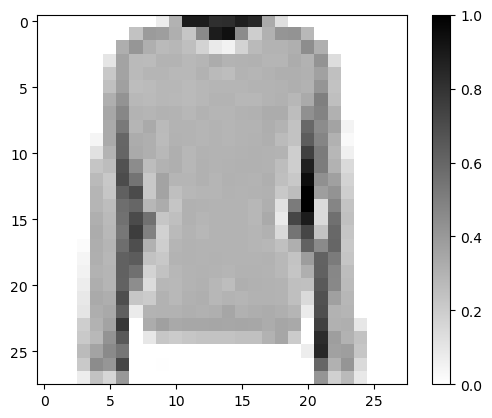

In [11]:
for imagen , etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28,28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

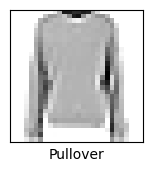

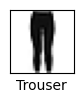

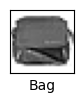

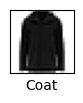

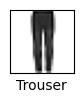

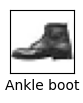

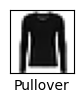

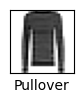

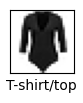

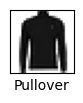

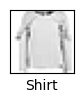

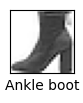

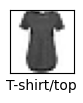

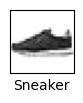

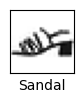

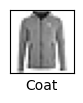

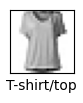

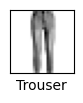

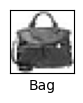

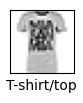

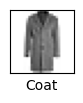

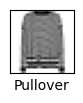

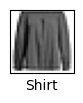

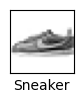

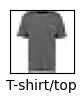

In [13]:
plt.figure(figsize=(10,10))
for i, (imagen,etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
    plt.show()

In [18]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) 
])

C:\Users\jedua\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
modelo.compile(
    optimizer = "adam",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [22]:
TAMANO_LOTE = 32

In [23]:
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples
print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


In [25]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

In [26]:
historial = modelo.fit(datos_entrenamiento, epochs =5, steps_per_epoch= math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8209 - loss: 0.5105
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8619 - loss: 0.3863
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8730 - loss: 0.3495
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8803 - loss: 0.3262
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8870 - loss: 0.3061


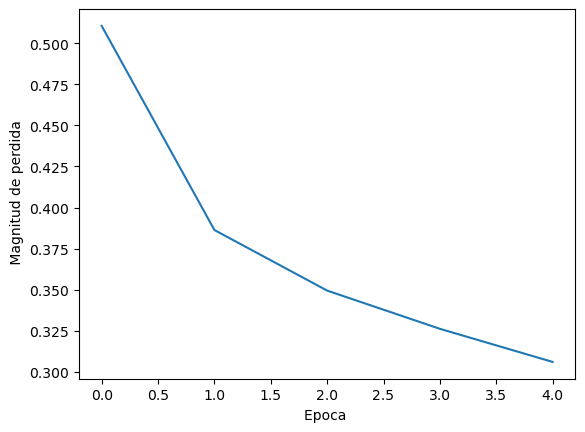

In [28]:
plt.xlabel("Epoca ")
plt.ylabel(" Magnitud de perdida")
plt.plot(historial.history["loss"])

In [33]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[1], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)
    if etiqueta_prediccion == etiqueta_real:
        color = "blue"
    else:
        color = "red"

    plt.xlabel("{} {:2.0f}% ({})". format(nombres_clases[etiqueta_prediccion],
                                      100*np.max(arr_predicciones),
                                      nombres_clases[etiqueta_real]),
                                    color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


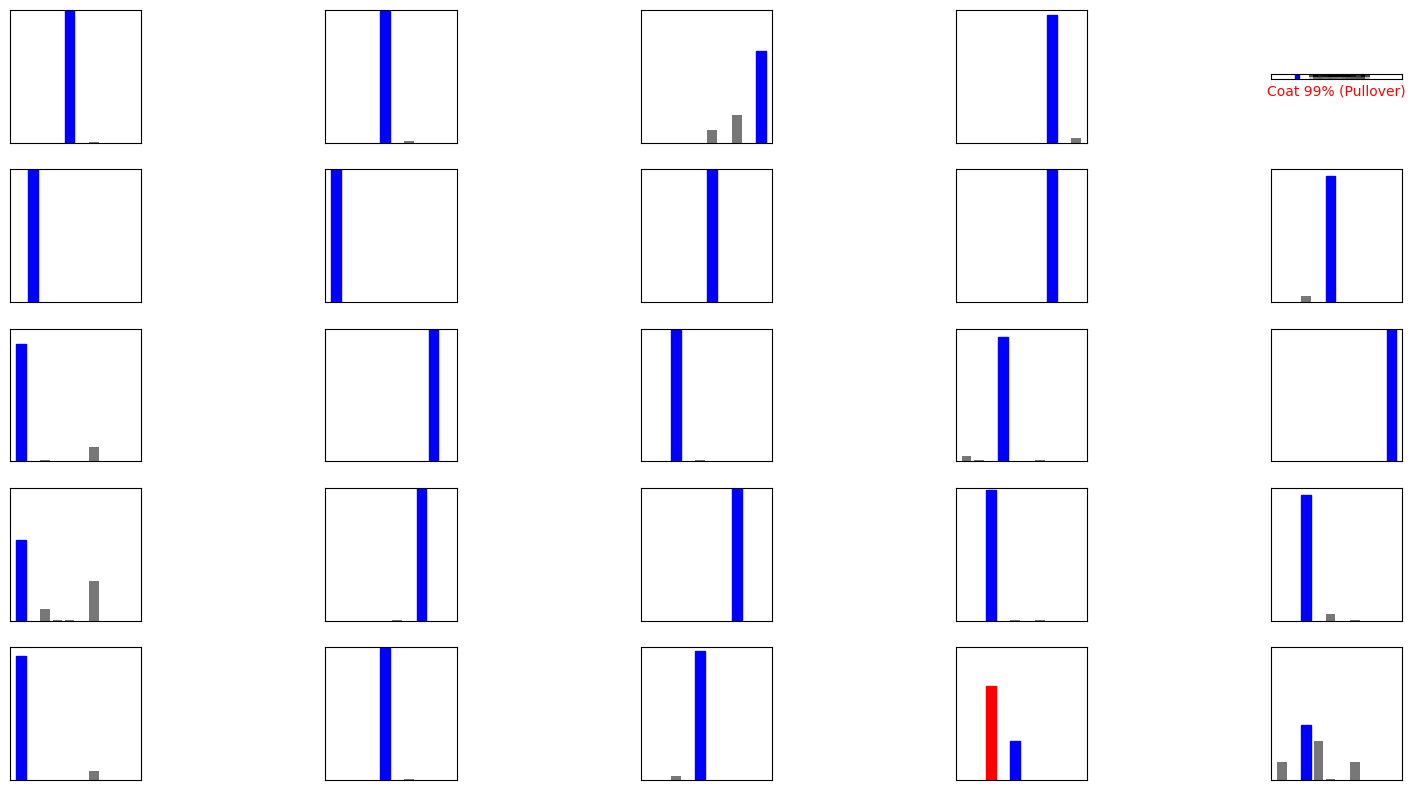

In [34]:
def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i],etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0,1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color("red")
    grafica[etiqueta_real].set_color("blue")


filas = 5
columnas = 5
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*filas)
    graficar_imagen(i,predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas,2*columnas, 2*i+2)
    graficar_valor_arreglo(i,predicciones,etiquetas_prueba)

In [35]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Prediccion: Pullover


**as_supervised** = Este parámetro se usa por que tf devuelve la emtrada y la etiqueta , si no se pone en true devuelve todo la infromacion y después cuando se usa fit(), espera unicamente 2 valores , los antes mencionados y causaria error.

**with_info** = para que aparte de que te de los datos , con ese parámtero te devuelve también los metadatos


**Formato H5**

Este formato es un estándar para almacenar grandes cantidades de datos numéricos, sirve para mantener la integridadde los datos entrenados , las conexiones.

In [36]:
# Guardar el modelo entrenado en formato H5
modelo.save('Act11.h5')
print("Modelo guardado correctamente")

Modelo guardado correctamente


In [4]:
def al_subir_imagen(change):
    output.clear_output()
    with output:
        # Obtener los bytes de la imagen subida
        archivo = list(boton_subir.value.values())[0]
        img_bytes = archivo['content']
        
        # Preprocesar: escala de grises, 28x28, normalizar (igual que el dataset)
        img = Image.open(io.BytesIO(img_bytes)).convert('L').resize((28, 28))
        arr = np.array(img, dtype=np.float32) / 255.0
        arr = arr.reshape(1, 28, 28, 1)
        
        # Predecir
        prediccion = modelo.predict(arr)
        clase = nombres_clases[np.argmax(prediccion[0])]
        confianza = 100 * np.max(prediccion[0])
        
        # Mostrar la imagen y el resultado
        plt.figure(figsize=(3, 3))
        plt.imshow(arr[0, ..., 0], cmap=plt.cm.binary)
        plt.title(f"Predicción: {clase}\nConfianza: {confianza:.1f}%")
        plt.axis('off')
        plt.show()
        print(f"Categoría detectada: {clase} ({confianza:.1f}%)")

In [3]:
boton_subir = widgets.FileUpload(accept='image/*', multiple=False)
output = widgets.Output()

In [5]:
boton_subir.observe(al_subir_imagen, names='value')

In [6]:
display(widgets.VBox([
    widgets.Label("Sube una imagen de ropa (JPG, PNG, etc.):"),
    boton_subir,
    output
]))